<b> 
    <font size="7">
        Computational Finance and FinTech <br><br>
        M.Sc. International Finance
    </font>
</b>
<br><br>
<img src="pics/HWR.png" width=400px>
<br><br>
<b>
    <font size="5"> 
        Prof. Dr. Natalie Packham <br>
        Berlin School of Economics and Law <br>
        Summer Term 2026
    </font>
</b>

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Input/Output-(IO)" data-toc-modified-id="Input/Output-(IO)-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Input/Output (IO)</a></span><ul class="toc-item"><li><span><a href="#Basic-IO-with-Python" data-toc-modified-id="Basic-IO-with-Python-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Basic IO with Python</a></span></li><li><span><a href="#CSV-files-with-pandas" data-toc-modified-id="CSV-files-with-pandas-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>CSV files with <code>pandas</code></a></span></li><li><span><a href="#Excel-files-with-pandas" data-toc-modified-id="Excel-files-with-pandas-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>Excel-files with <code>pandas</code></a></span></li><li><span><a href="#Saving-plots" data-toc-modified-id="Saving-plots-5.4"><span class="toc-item-num">5.4&nbsp;&nbsp;</span>Saving plots</a></span></li><li><span><a href="#Direct-download-from-the-internet:-pandas-datareader" data-toc-modified-id="Direct-download-from-the-internet:-pandas-datareader-5.5"><span class="toc-item-num">5.5&nbsp;&nbsp;</span>Direct download from the internet: <code>pandas-datareader</code></a></span></li></ul></li></ul></div>

# Input/Output (IO)

### Input / Output
* Further reading: __Py4Fi, Chapter 9__
* This chapter is about loading data from and storing data to a persistent data source (e.g. hard drive).
* Often financial data comes as `.csv`-files or `xlsx`- / `xls`-files. 
* Before working with the data it must be loaded into Python first. 
* Data can be loaded, written and stored using Python's built-in functions or `csv` or `pandas`.
* The book contains additional information on reading from and writing to SQL databases.

### Input / Output
* The usual initialisation:

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set()
import matplotlib.pyplot as plt

## Basic IO with Python

### CSV files
* A popular data format for working with spreadsheet-like data is __comma-separated values__, abbreviated as `.csv`. 
* In a csv file, data entries are stored in rows, with column separated by comma.
* The top row may contain the column names.

### CSV files
* Create a dummy data set to demonstrate how to work with csv files: 

In [4]:
rows = 10000 
a = np.random.standard_normal((rows, 5)).round(4)
a[:2]

array([[-0.6162, -2.1067,  0.2782,  0.0222,  1.4717],
       [ 1.1148,  2.1142,  2.0949, -1.9902,  0.3179]])

In [5]:
t = pd.date_range(start='2019/1/1', periods=rows, freq='h') # creates a DateTimeIndex

In [6]:
t[:4]

DatetimeIndex(['2019-01-01 00:00:00', '2019-01-01 01:00:00',
               '2019-01-01 02:00:00', '2019-01-01 03:00:00'],
              dtype='datetime64[us]', freq='h')

__Note:__ 'H' is used for an hourly frequency, see [here](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries-offset-aliases) for more information about the `freq` settings. 

### Creating a `.csv`-file in Python

* `open()` with the `w` flag creates an empty file.  

In [7]:
import os
path = os.getcwd() + '/' # the current working directory
path 

'/Users/uni/Documents/GitHub/compfin/'

In [8]:
csv_file = open(path + 'RandomNumbers.csv', 'w') # opens a file for writing
header = 'date,no1,no2,no3,no4,no5\n'
csv_file.write(header) # defines the header row and writes it as the first line

25

### Creating a `.csv`-file in Python

* The data is written to the `.csv`-file using Python's built-in function `write()`: 

In [9]:
for t_, (no1, no2, no3, no4, no5) in zip(t, a): # combines the data row-wise ...
    s = '{},{},{},{},{},{}\n'.format(t_, no1, no2, no3, no4, no5) # ... into string objects ...
    csv_file.write(s) # ... and writes it to the file line-by-line

* The changes are saved by calling `close()`.

In [10]:
csv_file.close()

In [11]:
ls -l RandomN* # Here it is!

-rw-r--r--@ 1 uni  staff  569355 May  6 15:31 RandomNumbers.csv
-rw-r--r--@ 1 uni  staff  579507 May  6 15:25 RandomNumbers_2.csv
-rw-r--r--@ 1 uni  staff  589466 May  6 15:30 RandomNumbers_3.csv


### Reading a `.csv`-file in Python

In [12]:
csv_file = open(path + 'RandomNumbers.csv', 'r') # open file for reading ('r')
RandomNumbers = csv_file.readlines() # read the file contents in one step
RandomNumbers[:5]

['date,no1,no2,no3,no4,no5\n',
 '2019-01-01 00:00:00,-0.6162,-2.1067,0.2782,0.0222,1.4717\n',
 '2019-01-01 01:00:00,1.1148,2.1142,2.0949,-1.9902,0.3179\n',
 '2019-01-01 02:00:00,0.1666,0.7849,-0.0651,-2.0137,1.4635\n',
 '2019-01-01 03:00:00,0.4404,0.4322,-0.7319,-1.1792,-1.2113\n']

In [13]:
csv_file.close() # close the file

### csv reader
* CSV files are so common that a dedicated package for reading (and writing) CSV files exists.

In [14]:
import csv

with open(path + 'RandomNumbers.csv', 'r') as f:
    numbers = csv.reader(f) # returns every line as a list object
    lines = [line for line in numbers] 

lines[:5]

[['date', 'no1', 'no2', 'no3', 'no4', 'no5'],
 ['2019-01-01 00:00:00', '-0.6162', '-2.1067', '0.2782', '0.0222', '1.4717'],
 ['2019-01-01 01:00:00', '1.1148', '2.1142', '2.0949', '-1.9902', '0.3179'],
 ['2019-01-01 02:00:00', '0.1666', '0.7849', '-0.0651', '-2.0137', '1.4635'],
 ['2019-01-01 03:00:00', '0.4404', '0.4322', '-0.7319', '-1.1792', '-1.2113']]

In [15]:
type(lines)

list

__Note:__ Aside of a `list`, the `csv` module can also return an `OrderedDict`, by using `DictReader()`. To learn more about the object `OrderedDict`, see [here](https://docs.python.org/3/library/collections.html#collections.OrderedDict).

### csv writer

* CSV files are easily written to a file using the `csv` package.

* Write the `.csv`-file, using the functions `writer()` and `writerow()`.

In [16]:
with open(path + 'RandomNumbers_2.csv', 'w') as f:
    numbers = csv.writer(f, delimiter = ',')
    for line in lines:
        numbers.writerow(line)

## CSV files with `pandas`

* Some of the data formats that `pandas` can read/write:
    * CSV (Comma-separated values)
    * SQL (Structured query language)
    * XLS / XLSX (Microsoft Excel files)
    * JSON (Javascript object notation)
    * HTML (Hyptertext markup language)

### CSV files with `pandas`
* Reading a CSV file with pandas loads the data into a `DataFrame` object.
* The first line of of the file is assumed to be the header.

In [17]:
df = pd.read_csv('RandomNumbers.csv')
# don't bother with the above stuff. start here

In [18]:
df.head()

,date,no1,no2,no3,no4,no5
0,2019-01-01 00:00:00,-0.6162,-2.1067,0.2782,0.0222,1.4717
1,2019-01-01 01:00:00,1.1148,2.1142,2.0949,-1.9902,0.3179
2,2019-01-01 02:00:00,0.1666,0.7849,-0.0651,-2.0137,1.4635
3,2019-01-01 03:00:00,0.4404,0.4322,-0.7319,-1.1792,-1.2113
4,2019-01-01 04:00:00,-0.7620,-0.2161,-1.4526,0.8250,0.5293


### CSV files with `pandas`
* `pd.read_csv()` adds an index by default. 
* To use a different index, add `set_index(columnName)`.

In [19]:
df.set_index('date', inplace=True)
df.head()

,no1,no2,no3,no4,no5
date,,,,,
2019-01-01 00:00:00,-0.6162,-2.1067,0.2782,0.0222,1.4717
2019-01-01 01:00:00,1.1148,2.1142,2.0949,-1.9902,0.3179
2019-01-01 02:00:00,0.1666,0.7849,-0.0651,-2.0137,1.4635
2019-01-01 03:00:00,0.4404,0.4322,-0.7319,-1.1792,-1.2113
2019-01-01 04:00:00,-0.7620,-0.2161,-1.4526,0.8250,0.5293


### Writing a `.csv`-file using `pandas`

In [20]:
df['no1'] = df['no1'] + 1000
df.to_csv('RandomNumbers_3.csv') # couldn't be easier...

## Excel-files with `pandas`
* Microsoft Excel files can be read and created easily using `pandas`.
* This is quite similar to reading / writing CSV files.

If the following line produces an error, then fix it by installing `openpyxl`:

``pip install openpyxl``

In [21]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [22]:
df.to_excel('RandomNumbers.xlsx')

In [23]:
ls -l RandomNumbers*

-rw-r--r--@ 1 uni  staff  569355 May  6 15:31 RandomNumbers.csv
-rw-r--r--@ 1 uni  staff  423004 May  6 15:31 RandomNumbers.xlsx
-rw-r--r--@ 1 uni  staff  579356 May  6 15:31 RandomNumbers_2.csv
-rw-r--r--@ 1 uni  staff  589436 May  6 15:31 RandomNumbers_3.csv


### Reading a `.xlsx`-file using `pandas`

In [24]:
df = pd.read_excel('RandomNumbers.xlsx', index_col=0)

In [25]:
df.head()

,no1,no2,no3,no4,no5
date,,,,,
2019-01-01 00:00:00,999.3838,-2.1067,0.2782,0.0222,1.4717
2019-01-01 01:00:00,1001.1148,2.1142,2.0949,-1.9902,0.3179
2019-01-01 02:00:00,1000.1666,0.7849,-0.0651,-2.0137,1.4635
2019-01-01 03:00:00,1000.4404,0.4322,-0.7319,-1.1792,-1.2113
2019-01-01 04:00:00,999.2380,-0.2161,-1.4526,0.8250,0.5293


## Saving plots 
* This section demonstrates how to make plots persistent for further processing. 
* The file format is typically detected by the file name extensions.

In [26]:
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

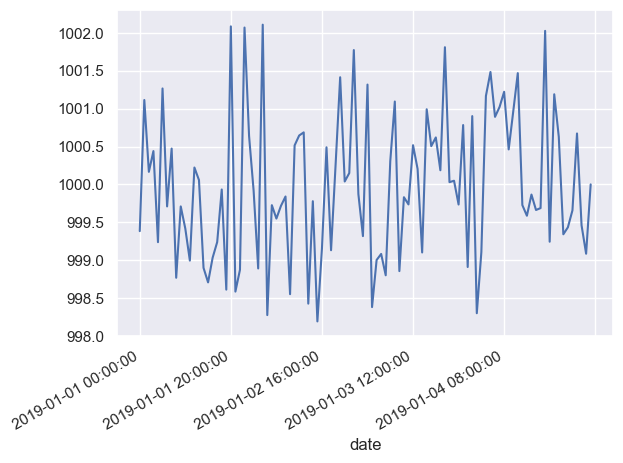

In [27]:
fig, ax = plt.subplots()
df['no1'][:100].plot()
fig.autofmt_xdate()
plt.savefig('LineChart.png')

### Generating a `pdf` plot

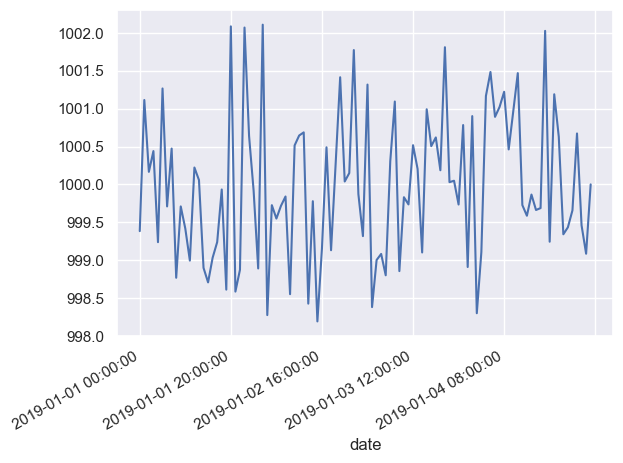

In [28]:
fig, ax = plt.subplots()
df['no1'][:100].plot()
fig.autofmt_xdate()
plt.savefig('LineChart.pdf')

### Generating plots

* There are various options for fine-tuning the appearance and quality of the plot. 
* Let's check that both plots have been written to the hard disk:

In [29]:
ls -l LineChart*

-rw-r--r--@ 1 uni  staff  10616 May  6 15:32 LineChart.pdf
-rw-r--r--@ 1 uni  staff  58913 May  6 15:31 LineChart.png


### Another pdf plot

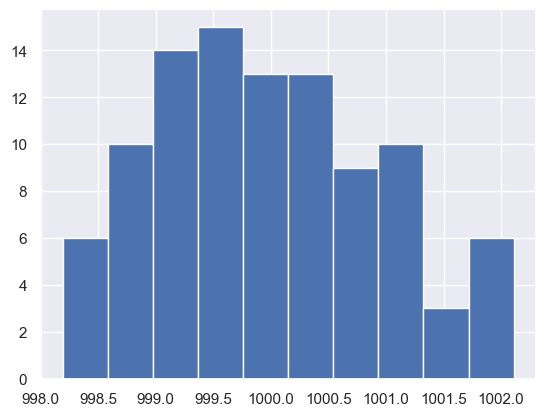

In [30]:
df['no1'][1:100].hist()
plt.savefig('Hist.pdf')

## Direct download from the internet: `pandas-datareader`

* Many data providers offer direct downloads through an API (application programming interface), an programming interface that controls data access and the data format.
* In other words, instead of manually downloading and subsequently importing a file, the data download can directly be incorporated into the program.
* The package `pandas-datareader` provides a convenient unified way of extracting data from various Internet sources into a pandas `DataFrame`.

### Installing `pandas-datareader`

* Installation via anaconda: go to environments in the left menubar, enter `datareader` in `search packages` and install. 
* Alternatively, use a terminal programme (command line) and type:  
    * `pip install pandas-datareader`  
* This is a frequently changing package... I had to use:
    * `pip install git+https://github.com/pydata/pandas-datareader.git`
* For more information, see [here](https://pandas-datareader.readthedocs.io/en/stable/index.html) and [here](https://anaconda.org/anaconda/pandas-datareader).

### Using `pandas-datareader`

Using TIINGO requires that you create a free account and obtain an API key.

In [8]:
pip install pandas-datareader

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import pandas_datareader as pdr

TypeError: deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'

In [4]:
df = pdr.get_data_tiingo('AAPL', api_key=os.getenv('TIINGO_API_KEY'))
df.head()

NameError: name 'pdr' is not defined

In [ ]:
df.tail()